# Agreement: Lineplot

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random
)

from monoculture.analysis.utils import load_model_outputs_same_prompt, get_metric
from monoculture.analysis.utils import load_task_data

from monoculture.analysis.metrics import observed_agreement_wrapper
from monoculture.analysis.plotting import plot_agreement_lineplot

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))
# from seaborn import color_palette
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000', ]
# #color_palette("colorblind")
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Blood_Pressure')


In [4]:
data = None

## Load predictions

In [5]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [6]:
df_same_prompt['task'].unique()

array(['ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime',
       'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure'],
      dtype=object)

In [7]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(328, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Blood_Pressure')

In [ ]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics: 
    df_same_prompt[metric] = df_same_prompt["eval_results_path"].apply(partial(get_metric, metric=metric)).copy()

evals_per_task_all = {} #[task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task['model'], df_task[metric])}
        for metric in metrics
    }

## Agreement at random - some notes

How often do models agree in the predictions they make? 
- **Note**: models that are more accuracte are also more likely to agree just by random chance
- We can correct for it
    - by deviding: report the factor by which the observation deviated
    - by substracting: report absolute deviation of observed from expected 
- When risk scores are turned into predictions not by their fitted threshold, but by cutting of at 0.5, we observe that in particular smaller models agree a lot, mainly because they are (almost) constant predictors. This highlights, that a deeper look into a model's behaviour is needed to explain the agreement rates (take model behavior into account). 

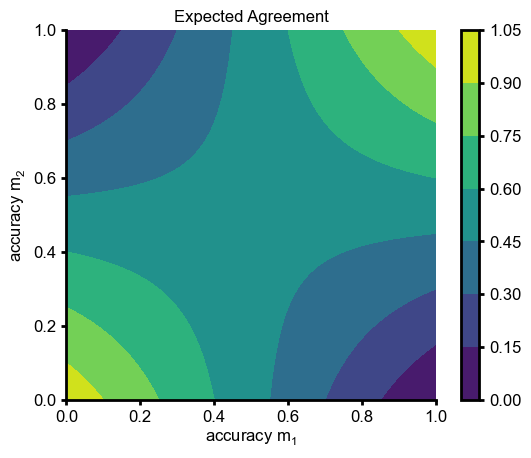

In [ ]:
fun = lambda a1,a2: a1*a2 + (1-a1)*(1-a2)
vals = np.arange(0,1.01, step=0.01)
xs, ys = np.meshgrid(vals,vals)
zs = xs*ys + (1-xs)*(1-ys)
plt.contourf(vals, vals, zs)
plt.axis('scaled')
plt.xlabel('accuracy $m_1$'); plt.ylabel('accuracy $m_2$'); plt.title('Expected Agreement')
plt.colorbar()
plt.show()
# cut-through
# plt.plot(vals, [fun(v,1-v) for v in vals])

## Restrict analysis to models based on performance or true labels?

In [ ]:
restrict_to_better_const = True
restrict_to_top_eps = True
restrict_to_topk = False
topk = 10
eps = 0.05
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()

if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps & restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]['accuracy'].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] >= top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

evals_per_task = {task : {metric : {model : evals_per_task_all[task][metric][model] for model in predictions[task].columns} for metric in evals_per_task_all[task].keys()} for task in evals_per_task_all.keys()}

ACSIncome
ACSEmployment
ACSTravelTime
ACSPublicCoverage


BRFSS_Blood_Pressure
ACSIncome (61233, 40)
ACSEmployment (146740, 42)
ACSTravelTime (64285, 19)
ACSPublicCoverage (33971, 12)
BRFSS_Blood_Pressure (44586, 34)
ACSIncome (61233, 21)
ACSEmployment (146740, 7)
ACSTravelTime (64285, 9)
ACSPublicCoverage (33971, 12)
BRFSS_Blood_Pressure (44586, 22)


KeyError: 'ACSMobility'

## Lineplot: Model Agreements Obs vs. Expected
*inspired by Mania et al. Fig 1a*

Sort model pairs by their agreement and plot the observed and expected model agreement

**Note:** obs and exp are sorted independently, thus there is not 1:1-correspondence between points at the same x (change by settiong sort_by to 'obs' or 'exp')

agreement-0-shot_tresh_fitted_better_const_pos_instances_eps0_05.png


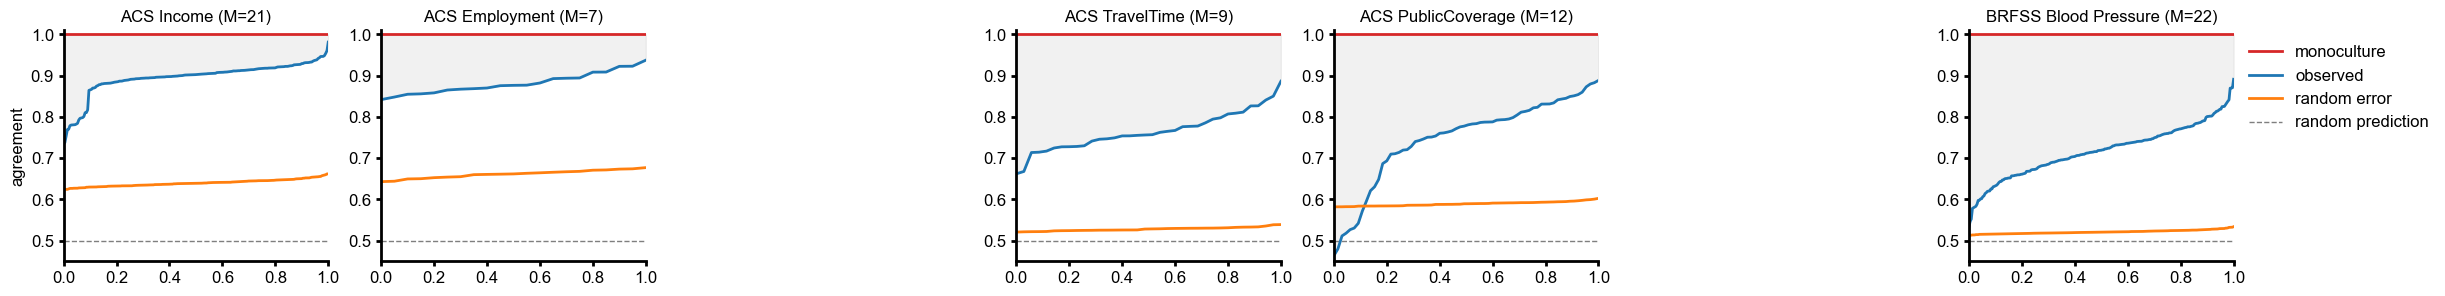

In [ ]:
tasks_to_plot = TASKS # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
    
sort_by = None
for i, task in enumerate(tasks_to_plot):
    if predictions[task].shape[1] > 0: 
        models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
        M = len(models_sorted)

        # agreements without diagonal
        obs_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            partial(observed_agreement_wrapper, predictions=predictions[task]),
        ).fill_diagonal_(torch.nan)
        exp_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            fun=lambda m1, m2: pairwise_agreement_at_random(
                evals_per_task[task]["accuracy"][m1], evals_per_task[task]["accuracy"][m2]
            ),
        ).fill_diagonal_(torch.nan)

        axs[i] = plot_agreement_lineplot(axs[i], 
                                    obs_agreement_matrix[~obs_agreement_matrix.isnan()], 
                                    exp_agreement_matrix[~exp_agreement_matrix.isnan()], 
                                    title=f"{task} (M={M})")
    else:
        axs[i].set_axis_off()

axs[0].set_ylabel("agreement")
axs[len(tasks_to_plot)//2-1].set_xlabel("fraction of model pairs")
# legend
handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))


file_name = "".join([
    f"agreement-{num_shots}-shot",
    "_tresh_fitted" if threshold_fitted == 1 else "", 
    "_better_const" if restrict_to_better_const else "",
    "_pos_instances" if restrict_to_positive_label else "",
    "_neg_instances" if restrict_to_negative_label else "",
    f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
    f"_top{topk}" if restrict_to_topk else "",
])
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    # plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()